In [1]:
import sys
sys.path.append('../../../')

In [2]:
from CADETProcess.processModel import ComponentSystem

component_system = ComponentSystem(["simulation"])

In [3]:
from CADETProcess.processModel import LumpedRateModelWithoutPores

zone_template = LumpedRateModelWithoutPores(
    component_system,
    "zone_template",
    total_porosity=0.7,
    length=2.2e-3,
    axial_dispersion=7e-9,
)

In [4]:
from CADETProcess.modelBuilder import ZRMFlowSheetBuilder

builder = ZRMFlowSheetBuilder(
    configuration = "axial",
    zone_template = zone_template,
    segments_area = [11.66e-04, 10.34e-04],
    void_in_volumes = [1.24e-06, 1.69e-06],
    void_out_volumes = [1.24e-06, 1.69e-06],
    name = "two_zonal_blocks"
)

flow_sheet_2 = builder.build_flow_sheet()

In [5]:
from CADETProcess.processModel import Inlet, Outlet

inlet = Inlet(component_system, "inlet")

flow_rate = 1e-6    # m^3/s
inlet.c = [1]       # mM
inlet.flow_rate = flow_rate

outlet = Outlet(component_system, "outlet")

In [6]:
from CADETProcess.processModel import TubularReactor

delay_tube = TubularReactor(component_system, "delay_tube")
delay_tube.length = 4.978
delay_tube.diameter = 0.001
delay_tube.axial_dispersion = 0  # no dispersion


In [7]:
flow_sheet_2.add_unit(inlet)
flow_sheet_2.add_unit(delay_tube)
flow_sheet_2.add_unit(outlet)

flow_sheet_2.add_connection(inlet, delay_tube)
flow_sheet_2.add_connection(delay_tube, builder.inlet_port)
flow_sheet_2.add_connection(builder.outlet_port, outlet)

In [8]:
from CADETProcess.processModel import Process
from CADETProcess.simulator import Cadet

simulator = Cadet()

process_2 = Process(flow_sheet_2, "two_zonal_blocks")
process_2.cycle_time = 50

results_2 = simulator.simulate(process_2)

C:\Users\ezeiry\AppData\Local\Temp\ipykernel_41100\868520798.py:18: DeprecationWarning: add_reference() is deprecated and will be removed in v1.0. Pass a pre-constructed metric instance to add_difference_metric() instead: metric = SSE(reference); comparator.add_difference_metric(metric, solution_path)
  comparator.add_reference(BTC)
C:\Users\ezeiry\AppData\Local\Temp\ipykernel_41100\868520798.py:19: DeprecationWarning: Passing a metric class name as a string to add_difference_metric() is deprecated and will be removed in v1.0. Construct the metric directly and pass the instance instead: metric = SSE(reference); comparator.add_difference_metric(metric, solution_path)
  comparator.add_difference_metric('RMSE', BTC, 'outlet.outlet')


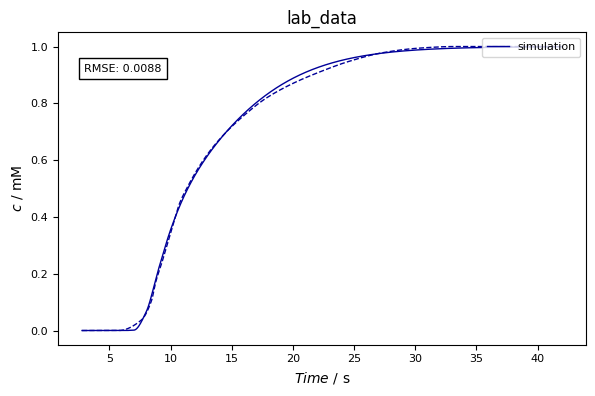

In [9]:
import numpy as np
from CADETProcess.reference import ReferenceIO

data = np.loadtxt('experimental_data/BSA_BTC_nonbinding.csv', delimiter=',')

time_experiment = data[:, 0]
c_experiment = data[:, 1]

from CADETProcess.reference import ReferenceIO
BTC = ReferenceIO(
    'lab_data', time_experiment, c_experiment
)


from CADETProcess.comparison import Comparator

comparator = Comparator('experimental_data/BSA_BTC_nonbinding.csv')
comparator.add_reference(BTC)
comparator.add_difference_metric('RMSE', BTC, 'outlet.outlet')
comparator.evaluate(results_2)


two_zones_plot = comparator.plot_comparison(results_2, x_axis_in_minutes=False, setup_figure_kwargs={"figsize": (6, 4)}) 

Using matplotlib backend: module://matplotlib_inline.backend_inline


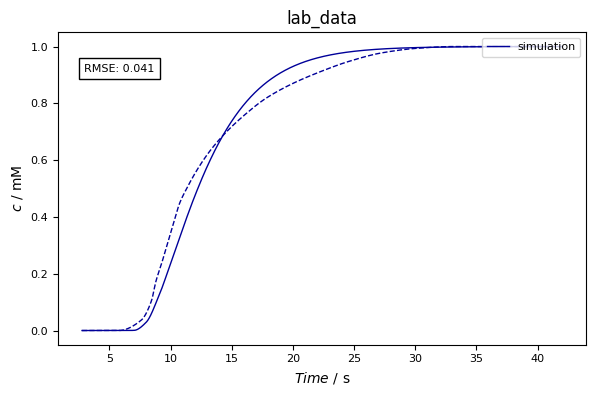

In [10]:
builder = ZRMFlowSheetBuilder(
    configuration="axial",
    zone_template=zone_template,
    segments_area=[22e-04],
    void_in_volumes=[2.93e-06],
    void_out_volumes=[2.93e-06],
    name = "one_zonal_block"

)


flow_sheet_1 = builder.build_flow_sheet()

flow_sheet_1.add_unit(inlet)
flow_sheet_1.add_unit(delay_tube)
flow_sheet_1.add_unit(outlet)

flow_sheet_1.add_connection(inlet, delay_tube)
flow_sheet_1.add_connection(delay_tube, builder.inlet_port)
flow_sheet_1.add_connection(builder.outlet_port, outlet)

process_1 = Process(flow_sheet_1, "one_zonal_block")
process_1.cycle_time = 50

results_1 = simulator.simulate(process_1)

%matplotlib
one_zones_plot = comparator.plot_comparison(results_1, x_axis_in_minutes=False, setup_figure_kwargs={"figsize": (6, 4)}) 

## Binding condition


